# XGBoost Model - Hyperparameter & Threshold Tuning

Optimized XGBoost classifier for recession prediction using the 36 selected features.

**Inputs:**
- `data/milestone_ii_preprocessed.pkl` (fully engineered features)
- `data/selected_features.pkl` (36 consensus features from Feature Selection)

**Pipeline:**
1. Data setup (identical to Baseline & Feature Selection)
2. Baseline reproduction with selected features
3. Hyperparameter tuning via RandomizedSearchCV
4. Threshold tuning (optimize F1 on validation folds)
5. Final model evaluation with tuned hyperparameters + threshold
6. Per-country analysis & feature importance

**Seeds:** `random_state=42` throughout for reproducibility and apples-to-apples comparison with Baseline.

In [70]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler
from sklearn.metrics import (
    classification_report, roc_auc_score, precision_recall_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
from scipy.stats import randint, uniform

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

RANDOM_STATE = 42
N_SPLITS = 5

# ── Load Data ─────────────────────────────────────────────────────────────────
df = pd.read_pickle('../data/milestone_ii_preprocessed.pkl')

with open('../data/selected_features.pkl', 'rb') as f:
    selected_features = pickle.load(f)

print(f'Dataset shape: {df.shape}')
print(f'Selected features: {len(selected_features)}')
print(f'Date range: {df.index.get_level_values("date").min()} to {df.index.get_level_values("date").max()}')
print(f'Countries: {df.index.get_level_values("country").unique().tolist()}')

Dataset shape: (5508, 237)
Selected features: 36
Date range: 1970-01-01 00:00:00 to 2020-12-01 00:00:00
Countries: ['Australia', 'Canada', 'France', 'Germany', 'Italy', 'Japan', 'South Korea', 'UK', 'USA']


In [71]:
# ── Data Preparation (identical to Baseline & Feature Selection) ────────────
df_flat = df.reset_index()
df_flat = df_flat[df_flat['date'] < '2019-01-01']  # Exclude pre-COVID contamination

X = df_flat[selected_features].copy()
y = df_flat['pre_recession']

# Replace inf/-inf with NaN (XGBoost handles NaN natively)
inf_count = np.isinf(X).sum().sum()
X = X.replace([np.inf, -np.inf], np.nan)

scale_pos_weight_global = (y == 0).sum() / (y == 1).sum()

print(f'Observations: {len(X)}')
print(f'Features: {len(selected_features)}')
print(f'Replaced {inf_count} infinite values with NaN')
print(f'Positive class: {y.sum()} ({y.mean():.1%})')
print(f'Global scale_pos_weight: {scale_pos_weight_global:.2f}')

Observations: 5292
Features: 36
Replaced 241 infinite values with NaN
Positive class: 1111 (21.0%)
Global scale_pos_weight: 3.76


## 1. Baseline Reproduction with Selected Features

Reproduce the baseline XGBoost configuration (identical hyperparameters) using only
the 36 selected features. This establishes the starting point for optimization.

In [72]:
# Baseline XGBoost config (same as Baseline & Feature Selection notebooks)
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
baseline_results = []
baseline_preds = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    test_countries = df_flat.iloc[test_idx]['country'].values

    spw = (y_train == 0).sum() / (y_train == 1).sum()

    model = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=spw,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0
    )
    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    roc = roc_auc_score(y_test, y_proba)
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_proba)
    pr = auc(rec_arr, prec_arr)
    f1 = f1_score(y_test, y_pred)

    baseline_results.append({'fold': fold + 1, 'roc_auc': roc, 'pr_auc': pr, 'f1': f1})
    baseline_preds.append(pd.DataFrame({
        'country': test_countries, 'y_true': y_test.values,
        'y_pred': y_pred, 'y_proba': y_proba, 'fold': fold + 1
    }))

    train_dates = df_flat.iloc[train_idx]['date']
    test_dates = df_flat.iloc[test_idx]['date']
    print(f'Fold {fold+1}: Train to {train_dates.max().strftime("%Y-%m")}, '
          f'Test {test_dates.min().strftime("%Y-%m")}-{test_dates.max().strftime("%Y-%m")} | '
          f'ROC-AUC: {roc:.3f} | PR-AUC: {pr:.3f} | F1: {f1:.3f}')

baseline_df = pd.DataFrame(baseline_results)
baseline_pred_df = pd.concat(baseline_preds, ignore_index=True)

print(f'\nBaseline (36 selected features, default hyperparameters):')
print(f'  Mean ROC-AUC: {baseline_df["roc_auc"].mean():.3f} ± {baseline_df["roc_auc"].std():.3f}')
print(f'  Mean PR-AUC:  {baseline_df["pr_auc"].mean():.3f} ± {baseline_df["pr_auc"].std():.3f}')
print(f'  Mean F1:      {baseline_df["f1"].mean():.3f} ± {baseline_df["f1"].std():.3f}')

Fold 1: Train to 1978-02, Test 1978-03-1986-04 | ROC-AUC: 0.689 | PR-AUC: 0.444 | F1: 0.236
Fold 2: Train to 1986-04, Test 1986-05-1994-06 | ROC-AUC: 0.724 | PR-AUC: 0.363 | F1: 0.278
Fold 3: Train to 1994-06, Test 1994-07-2002-08 | ROC-AUC: 0.769 | PR-AUC: 0.570 | F1: 0.578
Fold 4: Train to 2002-08, Test 2002-09-2010-10 | ROC-AUC: 0.815 | PR-AUC: 0.551 | F1: 0.522
Fold 5: Train to 2010-10, Test 2010-11-2018-12 | ROC-AUC: 0.617 | PR-AUC: 0.338 | F1: 0.256

Baseline (36 selected features, default hyperparameters):
  Mean ROC-AUC: 0.723 ± 0.076
  Mean PR-AUC:  0.453 ± 0.106
  Mean F1:      0.374 ± 0.163


## 2. Hyperparameter Tuning

Custom search loop with two key fixes over `RandomizedSearchCV`:

1. **Per-fold `scale_pos_weight`** — recomputed from each training fold's class
   balance (matching baseline), rather than a single global value
2. **Early stopping** — `n_estimators` up to 1000 with `early_stopping_rounds=30`,
   so the model auto-selects optimal tree count per fold instead of a fixed guess

**Two-stage search:**
- **Stage 1**: 150 random configurations (broad exploration)
- **Stage 2**: 50 perturbations around top-5 configs from Stage 1 (local refinement)

**Scoring:** PR-AUC is the primary metric (more informative than ROC-AUC for
imbalanced recession forecasting).

In [73]:
# ── Hyperparameter search configuration ──────────────────────────────────────
param_space = {
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.29),        # [0.01, 0.30]
    'subsample': uniform(0.6, 0.4),               # [0.6, 1.0]
    'colsample_bytree': uniform(0.5, 0.5),        # [0.5, 1.0]
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 5),                        # [0, 5]
    'reg_alpha': uniform(0, 2),                    # L1 [0, 2]
    'reg_lambda': uniform(0.5, 4.5),              # L2 [0.5, 5]
}

MAX_ROUNDS = 1000
EARLY_STOP = 30
N_STAGE1 = 150
N_STAGE2_PER_TOP = 10
TOP_K = 5

tscv = TimeSeriesSplit(n_splits=N_SPLITS)
folds = list(tscv.split(X))
rng = np.random.RandomState(RANDOM_STATE)


def evaluate_config(params):
    """Evaluate a hyperparameter config across all CV folds with per-fold SPW + early stopping."""
    fold_pr, fold_roc, fold_iters = [], [], []

    for train_idx, test_idx in folds:
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        spw = (y_train == 0).sum() / (y_train == 1).sum()

        model = xgb.XGBClassifier(
            n_estimators=MAX_ROUNDS,
            **params,
            scale_pos_weight=spw,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
            eval_metric='aucpr',
            early_stopping_rounds=EARLY_STOP,
        )
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

        y_proba = model.predict_proba(X_test)[:, 1]
        fold_roc.append(roc_auc_score(y_test, y_proba))
        prec, rec, _ = precision_recall_curve(y_test, y_proba)
        fold_pr.append(auc(rec, prec))
        fold_iters.append(model.best_iteration)

    return {
        'params': params,
        'mean_pr_auc': np.mean(fold_pr),
        'std_pr_auc': np.std(fold_pr),
        'mean_roc_auc': np.mean(fold_roc),
        'std_roc_auc': np.std(fold_roc),
        'mean_n_estimators': int(np.mean(fold_iters)),
    }


# ── Stage 1: Broad random search ────────────────────────────────────────────
print(f'Stage 1: Evaluating {N_STAGE1} random configurations...')
param_list = list(ParameterSampler(param_space, n_iter=N_STAGE1, random_state=RANDOM_STATE))

all_results = []
for i, params in enumerate(param_list):
    result = evaluate_config(params)
    all_results.append(result)
    if (i + 1) % 50 == 0:
        best = max(all_results, key=lambda x: x['mean_pr_auc'])
        print(f'  [{i+1}/{N_STAGE1}] Best PR-AUC so far: {best["mean_pr_auc"]:.4f}')

all_results.sort(key=lambda x: x['mean_pr_auc'], reverse=True)
print(f'\nStage 1 best: PR-AUC={all_results[0]["mean_pr_auc"]:.4f}  '
      f'ROC-AUC={all_results[0]["mean_roc_auc"]:.4f}  '
      f'n_estimators={all_results[0]["mean_n_estimators"]}')

# ── Stage 2: Refine around top configs ───────────────────────────────────────
print(f'\nStage 2: Refining top {TOP_K} configs ({N_STAGE2_PER_TOP} perturbations each)...')
n_stage1 = len(all_results)

for rank in range(TOP_K):
    base = all_results[rank]['params']
    for _ in range(N_STAGE2_PER_TOP):
        perturbed = {}
        for key, val in base.items():
            if isinstance(val, int):
                perturbed[key] = max(1, val + rng.randint(-1, 2))
            else:
                perturbed[key] = max(0.001, val * (1.0 + rng.uniform(-0.15, 0.15)))
        # Clip to valid ranges
        perturbed['max_depth'] = int(np.clip(perturbed['max_depth'], 2, 12))
        perturbed['learning_rate'] = float(np.clip(perturbed['learning_rate'], 0.005, 0.5))
        perturbed['subsample'] = float(np.clip(perturbed['subsample'], 0.5, 1.0))
        perturbed['colsample_bytree'] = float(np.clip(perturbed['colsample_bytree'], 0.3, 1.0))
        perturbed['min_child_weight'] = int(np.clip(perturbed['min_child_weight'], 1, 15))
        perturbed['gamma'] = float(np.clip(perturbed['gamma'], 0, 10))
        perturbed['reg_alpha'] = float(np.clip(perturbed['reg_alpha'], 0, 5))
        perturbed['reg_lambda'] = float(np.clip(perturbed['reg_lambda'], 0.1, 10))

        result = evaluate_config(perturbed)
        all_results.append(result)

all_results.sort(key=lambda x: x['mean_pr_auc'], reverse=True)
best_result = all_results[0]

# Set best_params including optimal n_estimators from early stopping
best_params = {**best_result['params'], 'n_estimators': best_result['mean_n_estimators']}

print(f'\nSearch complete ({n_stage1} + {len(all_results) - n_stage1} = {len(all_results)} configs evaluated)')
print(f'Best PR-AUC: {best_result["mean_pr_auc"]:.4f} ± {best_result["std_pr_auc"]:.4f}')
print(f'Best ROC-AUC: {best_result["mean_roc_auc"]:.4f} ± {best_result["std_roc_auc"]:.4f}')
print(f'Optimal n_estimators (from early stopping): {best_result["mean_n_estimators"]}')
print(f'\nBest hyperparameters:')
for param, val in sorted(best_params.items()):
    print(f'  {param}: {val:.4f}' if isinstance(val, float) else f'  {param}: {val}')

Stage 1: Evaluating 150 random configurations...
  [50/150] Best PR-AUC so far: 0.4962
  [100/150] Best PR-AUC so far: 0.4962
  [150/150] Best PR-AUC so far: 0.4962

Stage 1 best: PR-AUC=0.4962  ROC-AUC=0.7416  n_estimators=30

Stage 2: Refining top 5 configs (10 perturbations each)...

Search complete (150 + 50 = 200 configs evaluated)
Best PR-AUC: 0.4981 ± 0.1153
Best ROC-AUC: 0.7489 ± 0.0644
Optimal n_estimators (from early stopping): 40

Best hyperparameters:
  colsample_bytree: 1.0000
  gamma: 0.7280
  learning_rate: 0.1112
  max_depth: 3
  min_child_weight: 3
  n_estimators: 40
  reg_alpha: 2.1213
  reg_lambda: 3.9678
  subsample: 0.7070


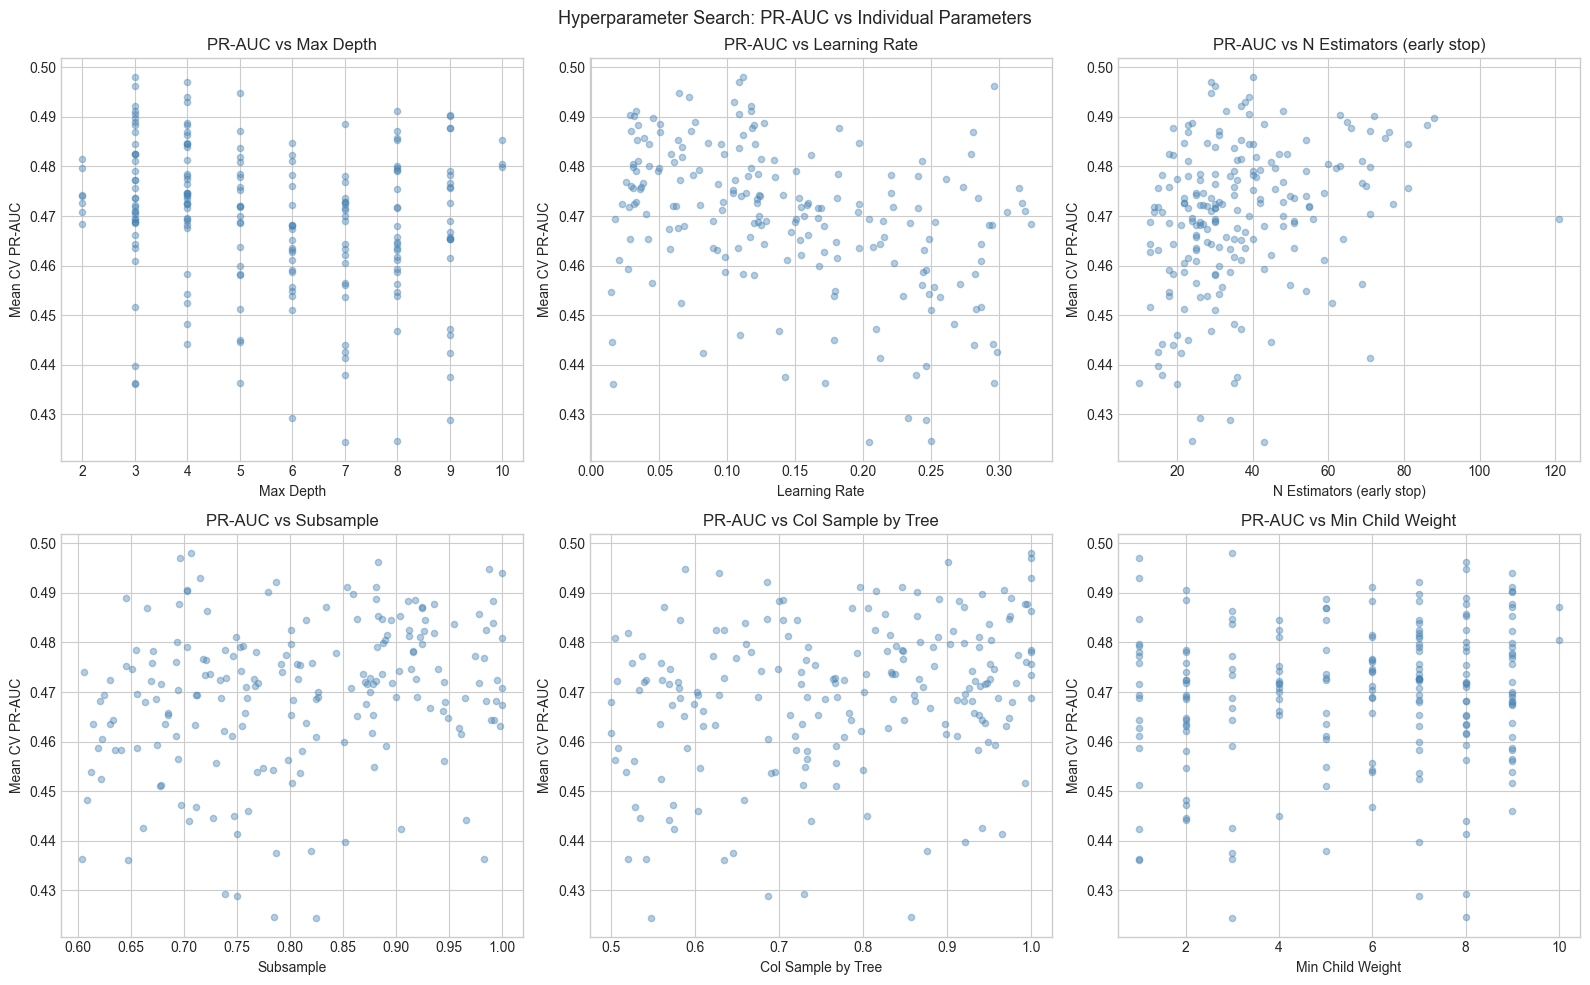

Top 10 configurations:
 mean_pr_auc  std_pr_auc  mean_roc_auc  mean_n_estimators  max_depth  learning_rate  subsample  colsample_bytree
      0.4981      0.1153        0.7489                 40          3         0.1112     0.7070            1.0000
      0.4971      0.1061        0.7473                 29          4         0.1089     0.6968            1.0000
      0.4962      0.1051        0.7416                 30          3         0.2962     0.8827            0.9011
      0.4947      0.0963        0.7537                 29          5         0.0641     0.9876            0.5883
      0.4939      0.0874        0.7590                 39          4         0.0715     1.0000            0.6288
      0.4931      0.1015        0.7426                 38          4         0.1052     0.7152            1.0000
      0.4922      0.1221        0.7545                 37          3         0.1173     0.7867            0.6857
      0.4913      0.1116        0.7524                 33          3     

In [74]:
# Build results DataFrame for analysis
results_rows = []
for r in all_results:
    row = {
        'mean_pr_auc': r['mean_pr_auc'],
        'std_pr_auc': r['std_pr_auc'],
        'mean_roc_auc': r['mean_roc_auc'],
        'mean_n_estimators': r['mean_n_estimators'],
    }
    row.update(r['params'])
    results_rows.append(row)
results_df = pd.DataFrame(results_rows)

# Scatter plots: PR-AUC vs key hyperparameters
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
params_to_plot = ['max_depth', 'learning_rate', 'mean_n_estimators',
                  'subsample', 'colsample_bytree', 'min_child_weight']
titles = ['Max Depth', 'Learning Rate', 'N Estimators (early stop)',
          'Subsample', 'Col Sample by Tree', 'Min Child Weight']

for ax, param, title in zip(axes.flat, params_to_plot, titles):
    ax.scatter(
        results_df[param].astype(float),
        results_df['mean_pr_auc'],
        alpha=0.4, s=20, c='steelblue'
    )
    ax.set_xlabel(title)
    ax.set_ylabel('Mean CV PR-AUC')
    ax.set_title(f'PR-AUC vs {title}')

plt.suptitle('Hyperparameter Search: PR-AUC vs Individual Parameters', fontsize=13)
plt.tight_layout()
plt.show()

# Top 10 configurations
top10 = results_df.nlargest(10, 'mean_pr_auc')[
    ['mean_pr_auc', 'std_pr_auc', 'mean_roc_auc', 'mean_n_estimators',
     'max_depth', 'learning_rate', 'subsample', 'colsample_bytree']
].round(4)
print('Top 10 configurations:')
print(top10.to_string(index=False))

## 2b. Hyperparameter Tuning with Optuna (Bayesian Optimization)

**Optuna** uses Tree-structured Parzen Estimators (TPE) — a Bayesian approach that
models the search space and focuses on promising regions, unlike the random/grid
search above.

- Same search space, per-fold `scale_pos_weight`, and early stopping as the
  random search for a fair comparison
- **200 trials** (same total budget as Stage 1 + Stage 2)
- **Scoring:** PR-AUC (same primary metric)
- Optuna's pruning is disabled since we already use XGBoost early stopping

In [75]:
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

N_OPTUNA_TRIALS = 200


def optuna_objective(trial):
    """Optuna objective: maximize mean PR-AUC across CV folds."""
    params = {
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.30, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 5.0),
    }

    fold_pr, fold_roc, fold_iters = [], [], []
    for train_idx, test_idx in folds:
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        spw = (y_train == 0).sum() / (y_train == 1).sum()

        model = xgb.XGBClassifier(
            n_estimators=MAX_ROUNDS,
            **params,
            scale_pos_weight=spw,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
            eval_metric='aucpr',
            early_stopping_rounds=EARLY_STOP,
        )
        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

        y_proba = model.predict_proba(X_test)[:, 1]
        fold_roc.append(roc_auc_score(y_test, y_proba))
        prec, rec, _ = precision_recall_curve(y_test, y_proba)
        fold_pr.append(auc(rec, prec))
        fold_iters.append(model.best_iteration)

    trial.set_user_attr('mean_roc_auc', float(np.mean(fold_roc)))
    trial.set_user_attr('std_pr_auc', float(np.std(fold_pr)))
    trial.set_user_attr('mean_n_estimators', int(np.mean(fold_iters)))

    return float(np.mean(fold_pr))


# ── Run Optuna study ─────────────────────────────────────────────────────────
print(f'Optuna: Running {N_OPTUNA_TRIALS} trials with TPE sampler...')

study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name='xgboost_recession',
)
study.optimize(optuna_objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

# Extract best result
optuna_best_params = {
    **study.best_params,
    'n_estimators': study.best_trial.user_attrs['mean_n_estimators'],
}

print(f'\nOptuna search complete ({len(study.trials)} trials)')
print(f'Best PR-AUC: {study.best_value:.4f} ± {study.best_trial.user_attrs["std_pr_auc"]:.4f}')
print(f'Best ROC-AUC: {study.best_trial.user_attrs["mean_roc_auc"]:.4f}')
print(f'Optimal n_estimators (from early stopping): {optuna_best_params["n_estimators"]}')
print(f'\nBest hyperparameters:')
for param, val in sorted(optuna_best_params.items()):
    print(f'  {param}: {val:.4f}' if isinstance(val, float) else f'  {param}: {val}')

c:\Users\Matthew\Desktop\School\Milestone 2\Repo\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Optuna: Running 200 trials with TPE sampler...


Best trial: 122. Best value: 0.509415: 100%|██████████| 200/200 [01:45<00:00,  1.89it/s]


Optuna search complete (200 trials)
Best PR-AUC: 0.5094 ± 0.1031
Best ROC-AUC: 0.7529
Optimal n_estimators (from early stopping): 33

Best hyperparameters:
  colsample_bytree: 0.9558
  gamma: 4.2154
  learning_rate: 0.1530
  max_depth: 5
  min_child_weight: 6
  n_estimators: 33
  reg_alpha: 0.6433
  reg_lambda: 4.4572
  subsample: 0.9118


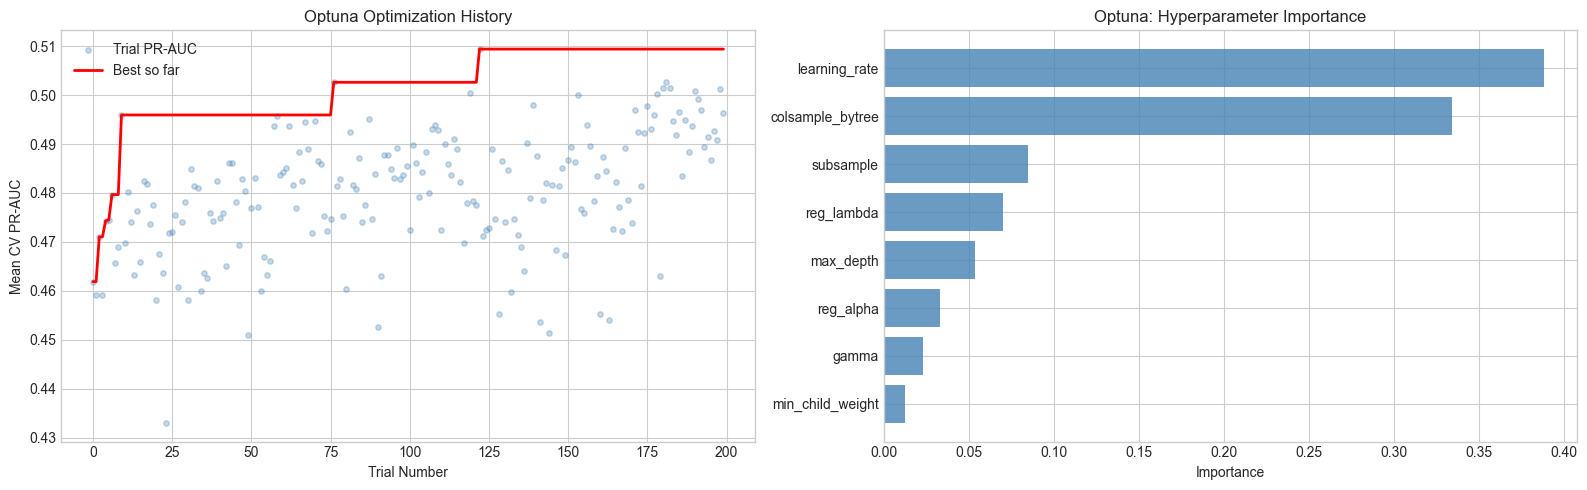

Random Search vs Optuna (Bayesian):
  Method                        PR-AUC    ROC-AUC
  ───────────────────────── ────────── ──────────
  Random (2-stage)              0.4981     0.7489
  Optuna (TPE)                  0.5094     0.7529

  → Optuna wins on PR-AUC by +0.0113

  Using Optuna (TPE) hyperparameters for downstream evaluation.
  best_params = {'max_depth': 5, 'learning_rate': 0.15304612820162758, 'subsample': 0.9117612799287361, 'colsample_bytree': 0.9557910628437146, 'min_child_weight': 6, 'gamma': 4.215389811697337, 'reg_alpha': 0.6432690763652238, 'reg_lambda': 4.4572157348343096, 'n_estimators': 33}


In [76]:
# ── Optuna visualizations ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Optimization history
trial_numbers = [t.number for t in study.trials]
trial_values = [t.value for t in study.trials]
best_so_far = np.maximum.accumulate(trial_values)

axes[0].scatter(trial_numbers, trial_values, alpha=0.3, s=15, c='steelblue', label='Trial PR-AUC')
axes[0].plot(trial_numbers, best_so_far, color='red', linewidth=2, label='Best so far')
axes[0].set_xlabel('Trial Number')
axes[0].set_ylabel('Mean CV PR-AUC')
axes[0].set_title('Optuna Optimization History')
axes[0].legend()

# Hyperparameter importance (via fANOVA-style variance)
importances = optuna.importance.get_param_importances(study)
params_sorted = list(importances.keys())
values_sorted = list(importances.values())

axes[1].barh(params_sorted[::-1], values_sorted[::-1], color='steelblue', alpha=0.8)
axes[1].set_xlabel('Importance')
axes[1].set_title('Optuna: Hyperparameter Importance')

plt.tight_layout()
plt.show()

# ── Compare Random Search vs Optuna ──────────────────────────────────────────
rs_best_pr = best_result['mean_pr_auc']
rs_best_roc = best_result['mean_roc_auc']
op_best_pr = study.best_value
op_best_roc = study.best_trial.user_attrs['mean_roc_auc']

print('Random Search vs Optuna (Bayesian):')
print(f'  {"Method":<25s} {"PR-AUC":>10s} {"ROC-AUC":>10s}')
print(f'  {"─" * 25} {"─" * 10} {"─" * 10}')
print(f'  {"Random (2-stage)":<25s} {rs_best_pr:>10.4f} {rs_best_roc:>10.4f}')
print(f'  {"Optuna (TPE)":<25s} {op_best_pr:>10.4f} {op_best_roc:>10.4f}')

if op_best_pr > rs_best_pr:
    print(f'\n  → Optuna wins on PR-AUC by {op_best_pr - rs_best_pr:+.4f}')
    best_params = optuna_best_params
    best_search_method = 'Optuna (TPE)'
elif op_best_pr < rs_best_pr:
    print(f'\n  → Random search wins on PR-AUC by {rs_best_pr - op_best_pr:+.4f}')
    best_search_method = 'Random (2-stage)'
    # best_params already set from random search
else:
    print(f'\n  → Tied on PR-AUC — keeping random search result')
    best_search_method = 'Random (2-stage)'

print(f'\n  Using {best_search_method} hyperparameters for downstream evaluation.')
print(f'  best_params = {best_params}')

## 3. Evaluate Tuned Hyperparameters with Per-Fold Metrics

Re-run 5-fold time-series CV with the best hyperparameters (including
`n_estimators` determined by early stopping). `scale_pos_weight` is recomputed
per fold (consistent with baseline).

In [77]:
# best_params is set by the Random Search vs Optuna comparison cell above
tscv = TimeSeriesSplit(n_splits=N_SPLITS)
tuned_results = []
tuned_preds = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    test_countries = df_flat.iloc[test_idx]['country'].values

    spw = (y_train == 0).sum() / (y_train == 1).sum()

    model = xgb.XGBClassifier(
        **best_params,
        scale_pos_weight=spw,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
        eval_metric='aucpr'
    )
    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)

    roc = roc_auc_score(y_test, y_proba)
    prec_arr, rec_arr, _ = precision_recall_curve(y_test, y_proba)
    pr = auc(rec_arr, prec_arr)
    f1 = f1_score(y_test, y_pred)

    tuned_results.append({'fold': fold + 1, 'roc_auc': roc, 'pr_auc': pr, 'f1': f1})
    tuned_preds.append(pd.DataFrame({
        'country': test_countries, 'y_true': y_test.values,
        'y_pred': y_pred, 'y_proba': y_proba, 'fold': fold + 1
    }))

    train_dates = df_flat.iloc[train_idx]['date']
    test_dates = df_flat.iloc[test_idx]['date']
    print(f'Fold {fold+1}: Train to {train_dates.max().strftime("%Y-%m")}, '
          f'Test {test_dates.min().strftime("%Y-%m")}-{test_dates.max().strftime("%Y-%m")} | '
          f'ROC-AUC: {roc:.3f} | PR-AUC: {pr:.3f} | F1: {f1:.3f}')

tuned_df = pd.DataFrame(tuned_results)
tuned_pred_df = pd.concat(tuned_preds, ignore_index=True)

print(f'\nTuned hyperparameters (default threshold=0.5):')
print(f'  Mean ROC-AUC: {tuned_df["roc_auc"].mean():.3f} ± {tuned_df["roc_auc"].std():.3f}')
print(f'  Mean PR-AUC:  {tuned_df["pr_auc"].mean():.3f} ± {tuned_df["pr_auc"].std():.3f}')
print(f'  Mean F1:      {tuned_df["f1"].mean():.3f} ± {tuned_df["f1"].std():.3f}')

Fold 1: Train to 1978-02, Test 1978-03-1986-04 | ROC-AUC: 0.720 | PR-AUC: 0.441 | F1: 0.201
Fold 2: Train to 1986-04, Test 1986-05-1994-06 | ROC-AUC: 0.748 | PR-AUC: 0.411 | F1: 0.407
Fold 3: Train to 1994-06, Test 1994-07-2002-08 | ROC-AUC: 0.792 | PR-AUC: 0.608 | F1: 0.594
Fold 4: Train to 2002-08, Test 2002-09-2010-10 | ROC-AUC: 0.828 | PR-AUC: 0.602 | F1: 0.520
Fold 5: Train to 2010-10, Test 2010-11-2018-12 | ROC-AUC: 0.644 | PR-AUC: 0.373 | F1: 0.328

Tuned hyperparameters (default threshold=0.5):
  Mean ROC-AUC: 0.747 ± 0.070
  Mean PR-AUC:  0.487 ± 0.110
  Mean F1:      0.410 ± 0.155


## 4. Threshold Tuning

The default XGBoost threshold (0.5) is not necessarily optimal for imbalanced data.
We sweep thresholds using each validation fold's predictions to find the threshold
that maximizes F1 score across all folds, then evaluate the impact.

Optimal threshold (max mean F1): 0.17
  Mean F1 at optimal threshold:    0.431
  Mean Precision at threshold:     0.305
  Mean Recall at threshold:        0.795
  F1 at default threshold (0.50):  0.410


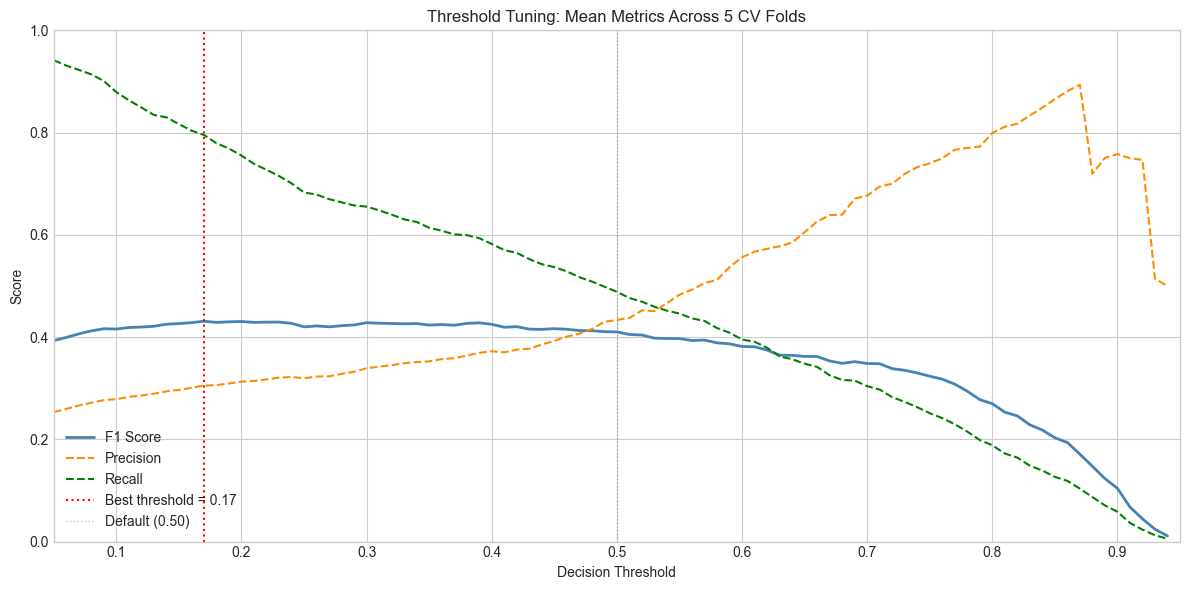

In [78]:
# Sweep thresholds on each validation fold, aggregate F1 scores
thresholds = np.arange(0.05, 0.95, 0.01)
fold_f1_by_threshold = np.zeros((N_SPLITS, len(thresholds)))
fold_precision_by_threshold = np.zeros((N_SPLITS, len(thresholds)))
fold_recall_by_threshold = np.zeros((N_SPLITS, len(thresholds)))

for fold_idx in range(N_SPLITS):
    fold_data = tuned_pred_df[tuned_pred_df['fold'] == fold_idx + 1]
    for j, thresh in enumerate(thresholds):
        y_pred_t = (fold_data['y_proba'] >= thresh).astype(int)
        fold_f1_by_threshold[fold_idx, j] = f1_score(
            fold_data['y_true'], y_pred_t, zero_division=0
        )
        fold_precision_by_threshold[fold_idx, j] = precision_score(
            fold_data['y_true'], y_pred_t, zero_division=0
        )
        fold_recall_by_threshold[fold_idx, j] = recall_score(
            fold_data['y_true'], y_pred_t, zero_division=0
        )

mean_f1 = fold_f1_by_threshold.mean(axis=0)
mean_precision = fold_precision_by_threshold.mean(axis=0)
mean_recall = fold_recall_by_threshold.mean(axis=0)

best_threshold_idx = np.argmax(mean_f1)
best_threshold = thresholds[best_threshold_idx]

print(f'Optimal threshold (max mean F1): {best_threshold:.2f}')
print(f'  Mean F1 at optimal threshold:    {mean_f1[best_threshold_idx]:.3f}')
print(f'  Mean Precision at threshold:     {mean_precision[best_threshold_idx]:.3f}')
print(f'  Mean Recall at threshold:        {mean_recall[best_threshold_idx]:.3f}')
print(f'  F1 at default threshold (0.50):  {mean_f1[np.argmin(np.abs(thresholds - 0.5))]:.3f}')

# Plot threshold sweep
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(thresholds, mean_f1, label='F1 Score', linewidth=2, color='steelblue')
ax.plot(thresholds, mean_precision, label='Precision', linewidth=1.5, color='darkorange', linestyle='--')
ax.plot(thresholds, mean_recall, label='Recall', linewidth=1.5, color='green', linestyle='--')
ax.axvline(best_threshold, color='red', linestyle=':', linewidth=1.5,
           label=f'Best threshold = {best_threshold:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='Default (0.50)')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Tuning: Mean Metrics Across 5 CV Folds')
ax.legend()
ax.set_xlim(0.05, 0.95)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [79]:
# Per-fold F1 at optimal threshold
print(f'Per-fold F1 at optimal threshold ({best_threshold:.2f}):')
for fold_idx in range(N_SPLITS):
    fold_data = tuned_pred_df[tuned_pred_df['fold'] == fold_idx + 1]
    y_pred_opt = (fold_data['y_proba'] >= best_threshold).astype(int)
    f1_opt = f1_score(fold_data['y_true'], y_pred_opt, zero_division=0)
    f1_def = f1_score(fold_data['y_true'], fold_data['y_pred'], zero_division=0)
    print(f'  Fold {fold_idx+1}: F1={f1_opt:.3f} (vs default: {f1_def:.3f}, '
          f'delta: {f1_opt - f1_def:+.3f})')

Per-fold F1 at optimal threshold (0.17):
  Fold 1: F1=0.478 (vs default: 0.201, delta: +0.277)
  Fold 2: F1=0.419 (vs default: 0.407, delta: +0.012)
  Fold 3: F1=0.531 (vs default: 0.594, delta: -0.062)
  Fold 4: F1=0.392 (vs default: 0.520, delta: -0.129)
  Fold 5: F1=0.335 (vs default: 0.328, delta: +0.007)


## 5. Final Model Evaluation

Combine the tuned hyperparameters with the optimal threshold. Run full CV
evaluation to produce the final performance metrics for comparison with the baseline.

In [80]:
# Re-apply optimal threshold to tuned predictions
tuned_pred_df['y_pred_opt'] = (tuned_pred_df['y_proba'] >= best_threshold).astype(int)

# Final per-fold metrics with optimal threshold
final_results = []
for fold_idx in range(N_SPLITS):
    fold_data = tuned_pred_df[tuned_pred_df['fold'] == fold_idx + 1]
    roc = roc_auc_score(fold_data['y_true'], fold_data['y_proba'])
    prec_arr, rec_arr, _ = precision_recall_curve(fold_data['y_true'], fold_data['y_proba'])
    pr = auc(rec_arr, prec_arr)
    f1 = f1_score(fold_data['y_true'], fold_data['y_pred_opt'], zero_division=0)
    prec = precision_score(fold_data['y_true'], fold_data['y_pred_opt'], zero_division=0)
    rec = recall_score(fold_data['y_true'], fold_data['y_pred_opt'], zero_division=0)
    acc = accuracy_score(fold_data['y_true'], fold_data['y_pred_opt'])

    final_results.append({
        'fold': fold_idx + 1, 'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1, 'roc_auc': roc, 'pr_auc': pr
    })

final_df = pd.DataFrame(final_results)

print('Final Model: Per-Fold Metrics (tuned hyperparameters + optimal threshold)')
print('=' * 85)
print(final_df.to_string(index=False, float_format='{:.3f}'.format))
print(f'\nMean ± Std:')
for col in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']:
    print(f'  {col:12s}: {final_df[col].mean():.3f} ± {final_df[col].std():.3f}')

Final Model: Per-Fold Metrics (tuned hyperparameters + optimal threshold)
 fold  accuracy  precision  recall    f1  roc_auc  pr_auc
    1     0.693      0.405   0.582 0.478    0.720   0.441
    2     0.553      0.276   0.866 0.419    0.748   0.411
    3     0.558      0.376   0.906 0.531    0.792   0.608
    4     0.507      0.248   0.927 0.392    0.828   0.602
    5     0.506      0.221   0.696 0.335    0.644   0.373

Mean ± Std:
  accuracy    : 0.563 ± 0.076
  precision   : 0.305 ± 0.081
  recall      : 0.795 ± 0.150
  f1          : 0.431 ± 0.076
  roc_auc     : 0.747 ± 0.070
  pr_auc      : 0.487 ± 0.110


In [81]:
# Per-country metrics with final model (including PR-AUC)
country_metrics = []
for country in sorted(tuned_pred_df['country'].unique()):
    mask = tuned_pred_df['country'] == country
    yt = tuned_pred_df.loc[mask, 'y_true']
    yp = tuned_pred_df.loc[mask, 'y_pred_opt']
    yprob = tuned_pred_df.loc[mask, 'y_proba']

    if yt.nunique() > 1:
        roc_val = roc_auc_score(yt, yprob)
        prec_curve, rec_curve, _ = precision_recall_curve(yt, yprob)
        pr_val = auc(rec_curve, prec_curve)
    else:
        roc_val = np.nan
        pr_val = np.nan

    metrics = {
        'Country': country,
        'Accuracy': accuracy_score(yt, yp),
        'Precision': precision_score(yt, yp, zero_division=0),
        'Recall': recall_score(yt, yp, zero_division=0),
        'F1': f1_score(yt, yp, zero_division=0),
        'ROC-AUC': roc_val,
        'PR-AUC': pr_val,
        'Support (pos)': int(yt.sum()),
        'Total': len(yt)
    }
    country_metrics.append(metrics)

country_df = pd.DataFrame(country_metrics).set_index('Country')

print('Per-Country Classification Metrics (Tuned Model, Aggregated Across All CV Folds)')
print('=' * 100)
print(country_df.to_string(float_format='{:.3f}'.format))

# Overall metrics
yt_all = tuned_pred_df['y_true']
yp_all = tuned_pred_df['y_pred_opt']
yprob_all = tuned_pred_df['y_proba']
prec_all, rec_all, _ = precision_recall_curve(yt_all, yprob_all)
print(f'\nOverall:  Accuracy={accuracy_score(yt_all, yp_all):.3f}  '
      f'Precision={precision_score(yt_all, yp_all, zero_division=0):.3f}  '
      f'Recall={recall_score(yt_all, yp_all, zero_division=0):.3f}  '
      f'F1={f1_score(yt_all, yp_all, zero_division=0):.3f}  '
      f'ROC-AUC={roc_auc_score(yt_all, yprob_all):.3f}  '
      f'PR-AUC={auc(rec_all, prec_all):.3f}')

Per-Country Classification Metrics (Tuned Model, Aggregated Across All CV Folds)
             Accuracy  Precision  Recall    F1  ROC-AUC  PR-AUC  Support (pos)  Total
Country                                                                              
Australia       0.553      0.315   0.862 0.462    0.702   0.378            109    490
Canada          0.439      0.238   0.661 0.350    0.610   0.381            112    490
France          0.702      0.358   0.758 0.486    0.820   0.624             91    490
Germany         0.635      0.360   0.843 0.504    0.790   0.527            108    490
Italy           0.635      0.328   0.923 0.484    0.867   0.665             91    490
Japan           0.543      0.324   0.870 0.472    0.697   0.458            115    490
South Korea     0.512      0.285   0.626 0.392    0.622   0.398            123    490
UK              0.484      0.222   0.750 0.343    0.681   0.437             88    490
USA             0.567      0.290   0.882 0.436    0.777   0

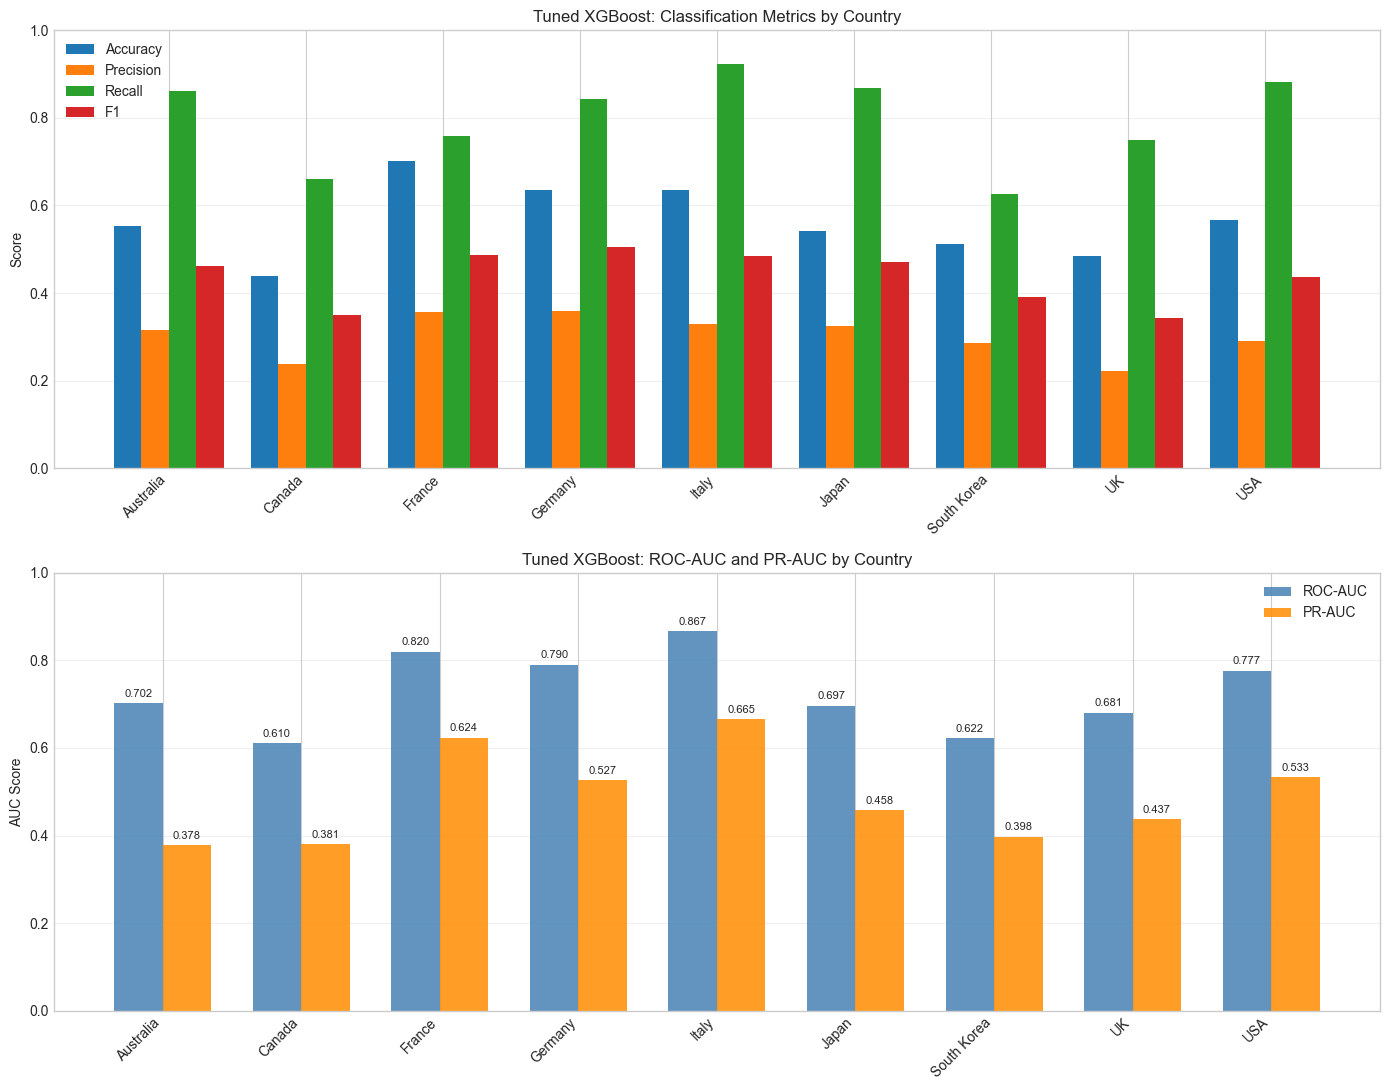

In [82]:
# Grouped bar chart: per-country metrics (including PR-AUC)
fig, axes = plt.subplots(2, 1, figsize=(14, 11))

# Classification metrics
plot_metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(country_df))
width = 0.2

for i, metric in enumerate(plot_metrics):
    axes[0].bar(x + i * width, country_df[metric], width, label=metric)

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(country_df.index, rotation=45, ha='right')
axes[0].set_ylabel('Score')
axes[0].set_title('Tuned XGBoost: Classification Metrics by Country')
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# ROC-AUC and PR-AUC side by side
width_auc = 0.35
axes[1].bar(x - width_auc / 2, country_df['ROC-AUC'], width_auc,
            label='ROC-AUC', color='steelblue', alpha=0.85)
axes[1].bar(x + width_auc / 2, country_df['PR-AUC'], width_auc,
            label='PR-AUC', color='darkorange', alpha=0.85)

# Add value labels on bars
for i, (roc_v, pr_v) in enumerate(zip(country_df['ROC-AUC'], country_df['PR-AUC'])):
    if not np.isnan(roc_v):
        axes[1].text(i - width_auc / 2, roc_v + 0.01, f'{roc_v:.3f}',
                     ha='center', va='bottom', fontsize=8)
    if not np.isnan(pr_v):
        axes[1].text(i + width_auc / 2, pr_v + 0.01, f'{pr_v:.3f}',
                     ha='center', va='bottom', fontsize=8)

axes[1].set_xticks(x)
axes[1].set_xticklabels(country_df.index, rotation=45, ha='right')
axes[1].set_ylabel('AUC Score')
axes[1].set_title('Tuned XGBoost: ROC-AUC and PR-AUC by Country')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 6. ROC and Precision-Recall Curves

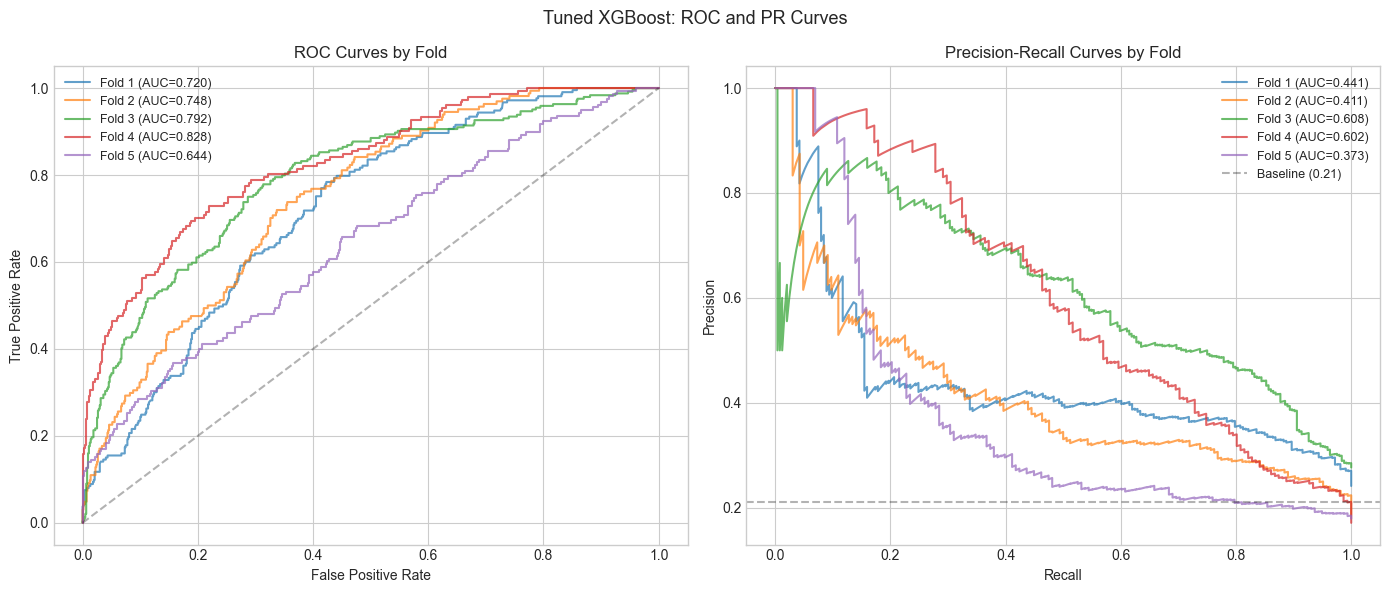

In [83]:
# ROC and PR curves per fold
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for fold_idx in range(N_SPLITS):
    fold_data = tuned_pred_df[tuned_pred_df['fold'] == fold_idx + 1]
    yt = fold_data['y_true']
    yp = fold_data['y_proba']

    # ROC curve
    fpr, tpr, _ = roc_curve(yt, yp)
    roc_val = roc_auc_score(yt, yp)
    axes[0].plot(fpr, tpr, label=f'Fold {fold_idx+1} (AUC={roc_val:.3f})', alpha=0.7)

    # PR curve
    prec_arr, rec_arr, _ = precision_recall_curve(yt, yp)
    pr_val = auc(rec_arr, prec_arr)
    axes[1].plot(rec_arr, prec_arr, label=f'Fold {fold_idx+1} (AUC={pr_val:.3f})', alpha=0.7)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves by Fold')
axes[0].legend(fontsize=9)

positive_rate = tuned_pred_df['y_true'].mean()
axes[1].axhline(positive_rate, color='k', linestyle='--', alpha=0.3, label=f'Baseline ({positive_rate:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves by Fold')
axes[1].legend(fontsize=9)

plt.suptitle('Tuned XGBoost: ROC and PR Curves', fontsize=13)
plt.tight_layout()
plt.show()

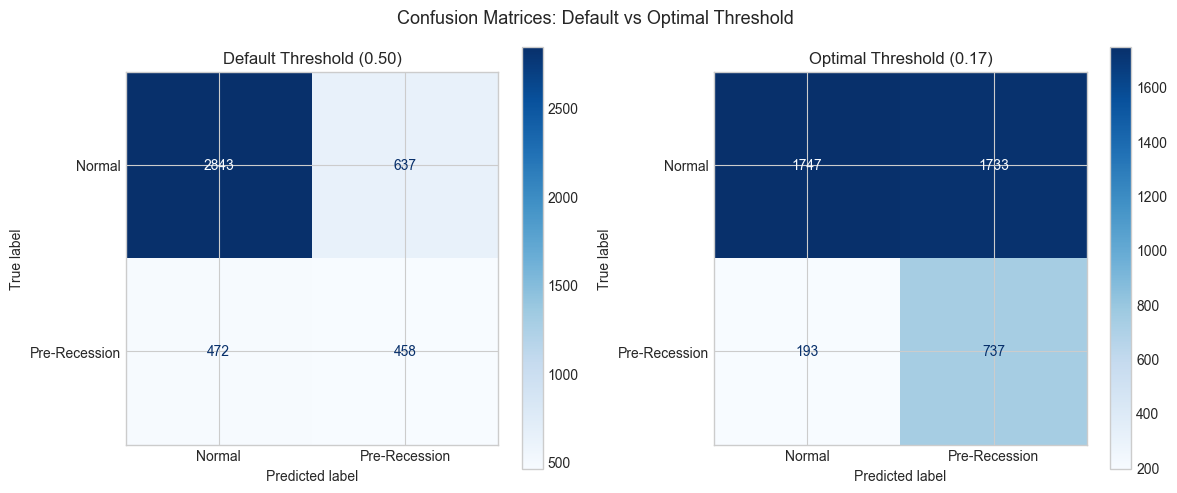

In [84]:
# Confusion matrix (aggregated across all folds)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Default threshold
cm_default = confusion_matrix(tuned_pred_df['y_true'], tuned_pred_df['y_pred'])
ConfusionMatrixDisplay(cm_default, display_labels=['Normal', 'Pre-Recession']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Default Threshold (0.50)')

# Optimal threshold
cm_optimal = confusion_matrix(tuned_pred_df['y_true'], tuned_pred_df['y_pred_opt'])
ConfusionMatrixDisplay(cm_optimal, display_labels=['Normal', 'Pre-Recession']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title(f'Optimal Threshold ({best_threshold:.2f})')

plt.suptitle('Confusion Matrices: Default vs Optimal Threshold', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Feature Importance

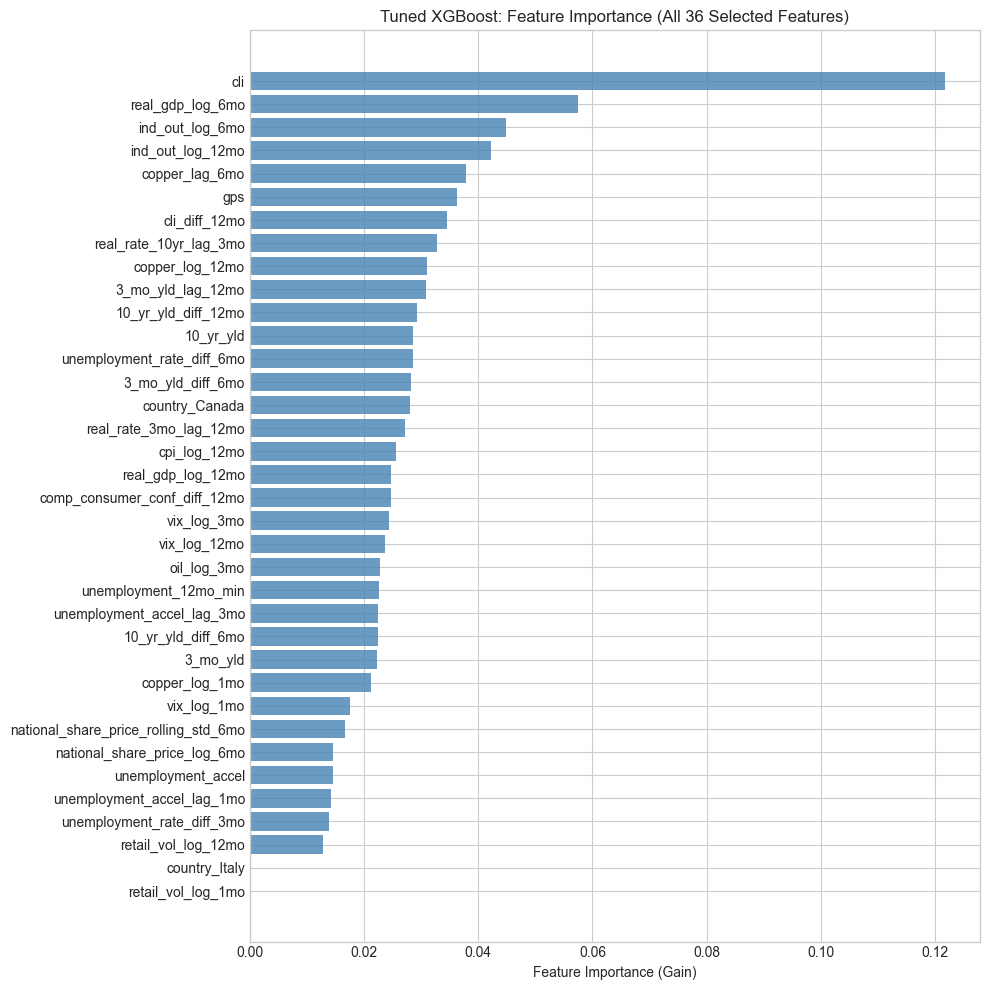

Feature Importance Ranking:
   1. cli                                                 0.1218
   2. real_gdp_log_6mo                                    0.0575
   3. ind_out_log_6mo                                     0.0449
   4. ind_out_log_12mo                                    0.0422
   5. copper_lag_6mo                                      0.0379
   6. gps                                                 0.0363
   7. cli_diff_12mo                                       0.0345
   8. real_rate_10yr_lag_3mo                              0.0328
   9. copper_log_12mo                                     0.0310
  10. 3_mo_yld_lag_12mo                                   0.0308
  11. 10_yr_yld_diff_12mo                                 0.0292
  12. 10_yr_yld                                           0.0286
  13. unemployment_rate_diff_6mo                          0.0285
  14. 3_mo_yld_diff_6mo                                   0.0281
  15. country_Canada                                      0.02

In [85]:
# Train final model on all training data for stable importance estimates
final_model = xgb.XGBClassifier(
    **best_params,
    scale_pos_weight=scale_pos_weight_global,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
    eval_metric='aucpr'
)
final_model.fit(X, y)

importances = pd.DataFrame({
    'feature': selected_features,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot all 36 features
fig, ax = plt.subplots(figsize=(10, 10))
plot_data = importances.sort_values('importance', ascending=True)
ax.barh(plot_data['feature'], plot_data['importance'], color='steelblue', alpha=0.8)
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('Tuned XGBoost: Feature Importance (All 36 Selected Features)')
plt.tight_layout()
plt.show()

print('Feature Importance Ranking:')
for i, (_, row) in enumerate(importances.iterrows(), 1):
    print(f'  {i:2d}. {row["feature"]:50s}  {row["importance"]:.4f}')

## 8. Baseline vs Tuned Comparison

Side-by-side comparison of the baseline (default hyperparameters, 0.5 threshold)
vs the tuned model (optimized hyperparameters + optimal threshold).

In [86]:
# Compute baseline metrics with default threshold for comparison
baseline_overall = {
    'Model': 'Baseline (default HP, t=0.50)',
    'Features': 36,
    'ROC-AUC': baseline_df['roc_auc'].mean(),
    'PR-AUC': baseline_df['pr_auc'].mean(),
    'F1': baseline_df['f1'].mean(),
    'Accuracy': accuracy_score(baseline_pred_df['y_true'], baseline_pred_df['y_pred']),
    'Precision': precision_score(baseline_pred_df['y_true'], baseline_pred_df['y_pred'], zero_division=0),
    'Recall': recall_score(baseline_pred_df['y_true'], baseline_pred_df['y_pred'], zero_division=0),
}

# Tuned with default threshold
tuned_default_t = {
    'Model': f'Tuned HP (t=0.50)',
    'Features': 36,
    'ROC-AUC': tuned_df['roc_auc'].mean(),
    'PR-AUC': tuned_df['pr_auc'].mean(),
    'F1': tuned_df['f1'].mean(),
    'Accuracy': accuracy_score(tuned_pred_df['y_true'], tuned_pred_df['y_pred']),
    'Precision': precision_score(tuned_pred_df['y_true'], tuned_pred_df['y_pred'], zero_division=0),
    'Recall': recall_score(tuned_pred_df['y_true'], tuned_pred_df['y_pred'], zero_division=0),
}

# Tuned with optimal threshold
tuned_opt_t = {
    'Model': f'Tuned HP + Threshold (t={best_threshold:.2f})',
    'Features': 36,
    'ROC-AUC': final_df['roc_auc'].mean(),
    'PR-AUC': final_df['pr_auc'].mean(),
    'F1': final_df['f1'].mean(),
    'Accuracy': accuracy_score(tuned_pred_df['y_true'], tuned_pred_df['y_pred_opt']),
    'Precision': precision_score(tuned_pred_df['y_true'], tuned_pred_df['y_pred_opt'], zero_division=0),
    'Recall': recall_score(tuned_pred_df['y_true'], tuned_pred_df['y_pred_opt'], zero_division=0),
}

comparison = pd.DataFrame([baseline_overall, tuned_default_t, tuned_opt_t]).set_index('Model')

print('Model Comparison (36 Selected Features)')
print('=' * 100)
print(comparison.to_string(float_format='{:.3f}'.format))

# Improvement deltas
print(f'\nImprovement (Tuned HP + Threshold vs Baseline):')
for col in ['ROC-AUC', 'PR-AUC', 'F1', 'Precision', 'Recall']:
    delta = comparison.loc[tuned_opt_t['Model'], col] - comparison.loc[baseline_overall['Model'], col]
    print(f'  {col:12s}: {delta:+.3f}')

Model Comparison (36 Selected Features)
                               Features  ROC-AUC  PR-AUC    F1  Accuracy  Precision  Recall
Model                                                                                      
Baseline (default HP, t=0.50)        36    0.723   0.453 0.374     0.776      0.462   0.384
Tuned HP (t=0.50)                    36    0.747   0.487 0.410     0.749      0.418   0.492
Tuned HP + Threshold (t=0.17)        36    0.747   0.487 0.431     0.563      0.298   0.792

Improvement (Tuned HP + Threshold vs Baseline):
  ROC-AUC     : +0.024
  PR-AUC      : +0.034
  F1          : +0.057
  Precision   : -0.163
  Recall      : +0.409


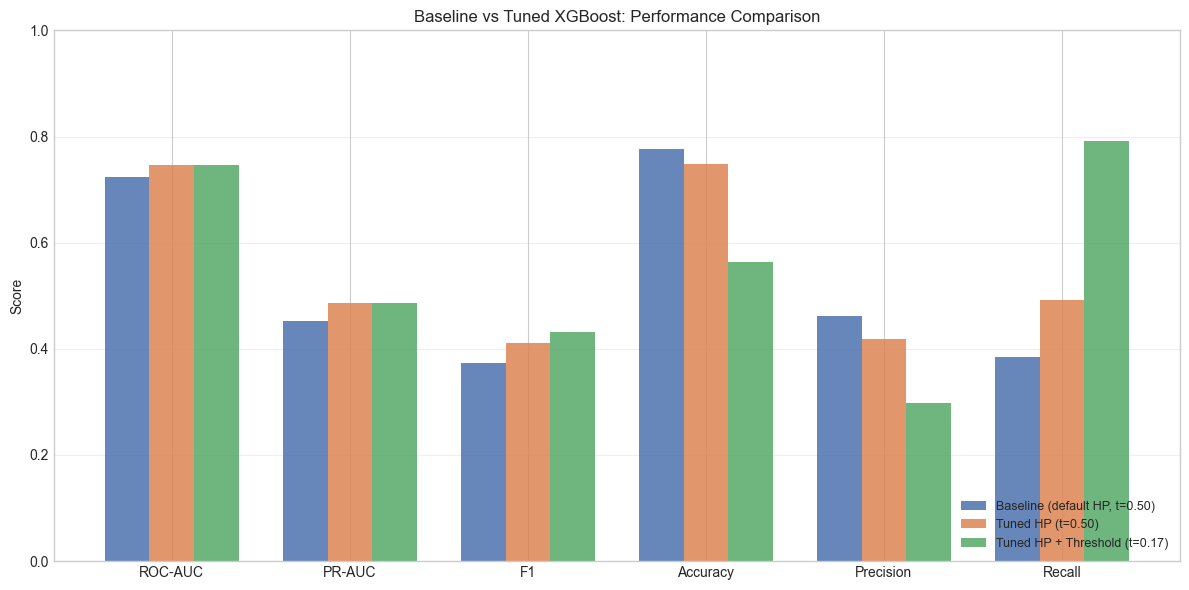

In [87]:
# Visual comparison
fig, ax = plt.subplots(figsize=(12, 6))

metrics_to_compare = ['ROC-AUC', 'PR-AUC', 'F1', 'Accuracy', 'Precision', 'Recall']
x = np.arange(len(metrics_to_compare))
width = 0.25

labels = comparison.index.tolist()
colors = ['#4C72B0', '#DD8452', '#55A868']

for i, (label, color) in enumerate(zip(labels, colors)):
    vals = [comparison.loc[label, m] for m in metrics_to_compare]
    ax.bar(x + i * width, vals, width, label=label, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_compare)
ax.set_ylabel('Score')
ax.set_title('Baseline vs Tuned XGBoost: Performance Comparison')
ax.set_ylim(0, 1)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Export Final Model Configuration

In [88]:
# Save the final model configuration for downstream use
model_config = {
    'best_params': best_params,
    'best_threshold': float(best_threshold),
    'selected_features': selected_features,
    'random_state': RANDOM_STATE,
    'n_cv_splits': N_SPLITS,
    'data_cutoff': '2019-01-01',
    'cv_metrics': {
        'roc_auc_mean': float(final_df['roc_auc'].mean()),
        'roc_auc_std': float(final_df['roc_auc'].std()),
        'pr_auc_mean': float(final_df['pr_auc'].mean()),
        'pr_auc_std': float(final_df['pr_auc'].std()),
        'f1_mean': float(final_df['f1'].mean()),
        'f1_std': float(final_df['f1'].std()),
    }
}

with open('../data/xgboost_model_config.pkl', 'wb') as f:
    pickle.dump(model_config, f)

print('Exported to: data/xgboost_model_config.pkl')
print(f'\nFinal Model Configuration:')
print(f'  Features:    {len(selected_features)}')
print(f'  Threshold:   {best_threshold:.2f}')
print(f'  Random state: {RANDOM_STATE}')
print(f'\n  Hyperparameters:')
for param, val in sorted(best_params.items()):
    print(f'    {param}: {val:.4f}' if isinstance(val, float) else f'    {param}: {val}')
print(f'\n  CV Performance:')
print(f'    ROC-AUC: {final_df["roc_auc"].mean():.3f} ± {final_df["roc_auc"].std():.3f}')
print(f'    PR-AUC:  {final_df["pr_auc"].mean():.3f} ± {final_df["pr_auc"].std():.3f}')
print(f'    F1:      {final_df["f1"].mean():.3f} ± {final_df["f1"].std():.3f}')

Exported to: data/xgboost_model_config.pkl

Final Model Configuration:
  Features:    36
  Threshold:   0.17
  Random state: 42

  Hyperparameters:
    colsample_bytree: 0.9558
    gamma: 4.2154
    learning_rate: 0.1530
    max_depth: 5
    min_child_weight: 6
    n_estimators: 33
    reg_alpha: 0.6433
    reg_lambda: 4.4572
    subsample: 0.9118

  CV Performance:
    ROC-AUC: 0.747 ± 0.070
    PR-AUC:  0.487 ± 0.110
    F1:      0.431 ± 0.076


## Summary

| Stage | Description |
|-------|-------------|
| Baseline reproduction | XGBoost with default HP on 36 selected features |
| Hyperparameter tuning (Random) | Two-stage search (150 random + 50 refined) with per-fold SPW + early stopping |
| Hyperparameter tuning (Optuna) | 200 trials with TPE Bayesian optimization, same search space + early stopping |
| Threshold tuning | Sweep 0.05-0.95, select threshold maximizing mean F1 across folds |
| Final evaluation | Best HP (from Random or Optuna) + optimal threshold, per-fold and per-country metrics |

**Two tuning approaches compared:**
- **Random (2-stage):** Broad exploration (150 configs) + local refinement around top-5 (50 perturbations)
- **Optuna (TPE):** Bayesian optimization via Tree-structured Parzen Estimators — models promising regions of the search space and focuses sampling there

**Key design choices (shared by both methods):**
- Per-fold `scale_pos_weight` (consistent with baseline, not a single global value)
- Early stopping (`n_estimators` up to 1000, stops after 30 rounds without improvement)
- PR-AUC as primary scoring metric (more informative than ROC-AUC for imbalanced data)

**Consistency with prior notebooks:**
- `random_state=42` for all models and searches
- `TimeSeriesSplit(n_splits=5)` for all cross-validation
- Data cutoff at 2019-01-01 (pre-COVID contamination excluded)
- `scale_pos_weight` recomputed per training fold
- Same leaky columns excluded (`oecd_rec`, `technical_rec`, `pre_recession`)

**Exported:** `data/xgboost_model_config.pkl` containing best hyperparameters, threshold, and CV metrics.